# Análisis de Correlaciones y Predicción de Eventos en Pozos ESP

Este notebook realiza un análisis exploratorio de datos (EDA) para entender las correlaciones entre variables operativas y la predicción de eventos en pozos de bombeo electro-sumergible (ESP). Se evalúan patrones de datos ausentes, se eliminan variables redundantes y se preparan insights para modelado predictivo.

**Objetivos:**
- Explorar la estructura del dataset y missingness.
- Analizar correlaciones de Pearson y Mutual Information (MI).
- Filtrar variables redundantes para optimizar el modelo.
- Preparar datos para estrategias de manejo de NaN (e.g., Opción B: indicadores de missingness).

**Dataset:** Datos operativos de pozos ESP desde 2015, con variables como presiones, caudales y slopes.

In [58]:
# 1. Configuración del Entorno y Librerías

import sys
import os
from pathlib import Path

# Agregar src al path para módulos personalizados
project_root = Path.cwd()
sys.path.append(str(project_root / 'src'))

# Librerías estándar
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Librerías de ML para correlaciones y feature selection
from sklearn.feature_selection import mutual_info_regression
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

# Suprimir warnings para limpieza
import warnings
warnings.filterwarnings('ignore')

# Configuración de visualización
plt.style.use('default')
sns.set_palette("husl")
pd.set_option('display.float_format', lambda x: f'{x:,.2f}')

print("Entorno configurado correctamente.")
print(f"Directorio de trabajo: {project_root}")

Entorno configurado correctamente.
Directorio de trabajo: c:\Users\Vìctor\OneDrive\Desktop\ESP_Project\notebooks


In [59]:
# 2. Carga del Dataset

# Ruta al archivo de datos más reciente
data_path = project_root.parent / 'freeze' / 'df_operativo_final_20251210_213817.csv'

# Cargar el dataset con manejo de memoria baja
df = pd.read_csv(data_path, low_memory=False)

print("Dataset cargado exitosamente.")
print(f"Dimensiones: {df.shape[0]} filas x {df.shape[1]} columnas")
print(f"Columnas principales: {list(df.columns[:])}...")

Dataset cargado exitosamente.
Dimensiones: 16161 filas x 54 columnas
Columnas principales: ['name_', 'date', 'prueba_de_produccion_petróleo_a_24_horas_bbld', 'prueba_de_producción_agua_a_24_horas_bbld', 'prueba_pozooil_24__prueba_pozowater_24', 'prueba_de_producción_gas_a_24_horas_mcfd', 'bsw_pct', 'gravedad_api_del_petroleo', 'salinidad_ppm_pu', 'presion_de_intake_psi', 'frecuencia_bomba_hz', 'amperaje_bomba_amp', 'presion_de_tubing_psi', 'presion_de_casing_psi', 'tipo_de_bomba', 'temperatura_de_la_bomba_deg_f', 'etapas_de_la_bomba', 'campo', 'delta_1', 'delta_3', 'slope_7', 'slope_14', 'evento_hibrido', 'Unnamed: 23', 'regimen_id', 'qtot_lo', 'qtot_hi', 'gas_hi', 'hz_hi', 'pint_lo', 'qtot_lo_p', 'qtot_hi_p', 'gas_hi_p', 'hz_hi_p', 'pint_lo_p', 'qtot_lo_eff', 'qtot_hi_eff', 'gas_hi_eff', 'hz_hi_eff', 'pint_lo_eff', 'env_q', 'env_gate', 'slope7_mean', 'slope7_std', 'd1_p', 'Qt_prev14', 'ratio14', 'confirm', 'enough', 'fuera_inst', 'alarma_instantanea', 'persist', 'persist_ref', 'pred_e

In [60]:
# 3. Exploración Inicial del Dataset

# Vista previa de las primeras filas
df.head()

,name_,date,prueba_de_produccion_petróleo_a_24_horas_bbld,prueba_de_producción_agua_a_24_horas_bbld,prueba_pozooil_24__prueba_pozowater_24,prueba_de_producción_gas_a_24_horas_mcfd,bsw_pct,gravedad_api_del_petroleo,salinidad_ppm_pu,presion_de_intake_psi,...,d1_p,Qt_prev14,ratio14,confirm,enough,fuera_inst,alarma_instantanea,persist,persist_ref,pred_evento
0,SCH-007U,2015-02-02,204.37,435.73,640.10,14.00,68.07,22.40,NaN,NaN,...,104.49,NaN,NaN,0,1,1,0,0,0,0
1,SCH-007U,2015-02-09,216.90,652.63,869.53,14.00,75.05,22.40,NaN,NaN,...,104.49,NaN,NaN,1,1,1,1,0,0,2
2,SCH-007U,2015-03-05,99.29,281.49,380.78,14.00,73.92,22.40,NaN,NaN,...,104.49,NaN,NaN,1,1,1,1,1,1,1
3,SCH-007U,2015-04-05,205.33,585.15,790.48,14.00,74.02,22.40,NaN,NaN,...,104.49,NaN,NaN,1,1,1,1,1,0,1
4,SCH-007U,2015-04-07,214.01,642.02,856.03,14.00,75.00,22.40,NaN,NaN,...,104.49,NaN,NaN,1,1,1,1,1,1,2


In [61]:
# Información general del dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16161 entries, 0 to 16160
Data columns (total 54 columns):
 #   Column                                         Non-Null Count  Dtype  
---  ------                                         --------------  -----  
 0   name_                                          16161 non-null  object 
 1   date                                           16161 non-null  object 
 2   prueba_de_produccion_petróleo_a_24_horas_bbld  16161 non-null  float64
 3   prueba_de_producción_agua_a_24_horas_bbld      16161 non-null  float64
 4   prueba_pozooil_24__prueba_pozowater_24         16161 non-null  float64
 5   prueba_de_producción_gas_a_24_horas_mcfd       16161 non-null  float64
 6   bsw_pct                                        16156 non-null  float64
 7   gravedad_api_del_petroleo                      16096 non-null  float64
 8   salinidad_ppm_pu                               13820 non-null  float64
 9   presion_de_intake_psi                          109

In [13]:
# Estadísticas descriptivas de variables numéricas
df.describe()

,prueba_de_produccion_petróleo_a_24_horas_bbld,prueba_de_producción_agua_a_24_horas_bbld,prueba_pozooil_24__prueba_pozowater_24,prueba_de_producción_gas_a_24_horas_mcfd,bsw_pct,gravedad_api_del_petroleo,salinidad_ppm_pu,presion_de_intake_psi,frecuencia_bomba_hz,amperaje_bomba_amp,...,d1_p,Qt_prev14,ratio14,confirm,enough,fuera_inst,alarma_instantanea,persist,persist_ref,pred_evento
count,"16,161.00","16,161.00","16,161.00","16,161.00","16,156.00","16,096.00","13,820.00","10,948.00","13,388.00","13,272.00",...,"16,161.00","15,518.00","15,518.00","16,161.00","16,161.00","16,161.00","16,161.00","16,161.00","16,161.00","16,161.00"
mean,369.33,866.90,"1,236.22",76.82,57.36,23.92,"16,503.79","1,014.36",63.87,39.06,...,117.28,"1,214.77",0.09,0.35,1.00,0.56,0.23,0.12,0.07,0.33
std,289.52,826.45,826.81,104.33,32.93,3.86,"18,399.41",839.27,23.31,17.24,...,111.28,820.31,0.52,0.48,0.00,0.50,0.42,0.32,0.26,0.66
min,11.00,0.60,33.80,0.00,0.35,16.40,17.20,16.05,35.00,8.00,...,30.92,33.80,-0.92,0.00,1.00,0.00,0.00,0.00,0.00,0.00
25%,180.00,179.00,592.00,20.50,24.01,19.70,"3,000.00",430.00,53.00,26.00,...,67.20,565.00,-0.04,0.00,1.00,0.00,0.00,0.00,0.00,0.00
50%,281.00,699.00,"1,144.00",48.72,72.01,24.30,"11,000.00",695.00,58.50,36.50,...,89.00,"1,124.00",0.00,0.00,1.00,1.00,0.00,0.00,0.00,0.00
75%,446.00,"1,200.00","1,594.00",90.37,84.00,26.80,"18,330.00","1,368.00",62.00,47.00,...,107.60,"1,583.00",0.06,1.00,1.00,1.00,0.00,0.00,0.00,0.00
max,"2,058.00","4,188.00","4,770.00","1,235.00",99.01,31.00,"85,800.00","26,664.00",178.00,147.00,...,"1,279.00","4,770.00",10.50,1.00,1.00,1.00,1.00,1.00,1.00,2.00


## 4. Análisis de Datos Ausentes (Missingness)

Los datos ausentes son comunes en series temporales industriales, especialmente en los primeros años de operación. Evaluamos patrones por variable, año y pozo para decidir estrategias de manejo (e.g., indicadores de missingness).

In [62]:
# Convertir columna de fecha si no está en datetime
df['date'] = pd.to_datetime(df['date'])

# Porcentaje de valores faltantes por variable
missing_pct = (df.isnull().sum() / len(df)) * 100
missing_pct = missing_pct.sort_values(ascending=False)

print("Porcentaje de valores faltantes por variable (top 20):")
print(missing_pct.head(20))

Porcentaje de valores faltantes por variable (top 20):
Unnamed: 23                     99.99
presion_de_casing_psi           68.13
temperatura_de_la_bomba_deg_f   40.75
presion_de_intake_psi           32.26
amperaje_bomba_amp              17.88
frecuencia_bomba_hz             17.16
salinidad_ppm_pu                14.49
etapas_de_la_bomba              12.51
tipo_de_bomba                   11.11
pint_lo                          9.80
hz_hi                            6.78
Qt_prev14                        3.98
ratio14                          3.98
qtot_hi                          1.50
qtot_lo                          1.50
gas_hi                           1.50
slope_14                         1.14
delta_3                          0.85
slope_7                          0.57
gravedad_api_del_petroleo        0.40
dtype: float64


In [63]:
# Missingness por año para variables críticas
df['year'] = df['date'].dt.year
variables_criticas = ['presion_de_intake_psi', 'frecuencia_bomba_hz', 'amperaje_bomba_amp', 
                      'presion_de_tubing_psi', 'temperatura_de_la_bomba_deg_f']

missing_by_year = df.groupby('year')[variables_criticas].apply(lambda x: x.isnull().mean() * 100)

print("Porcentaje de missingness por año (variables críticas):")
print(missing_by_year)

Porcentaje de missingness por año (variables críticas):
      presion_de_intake_psi  frecuencia_bomba_hz  amperaje_bomba_amp  \
year                                                                   
2012                 100.00               100.00              100.00   
2015                 100.00               100.00              100.00   
2016                 100.00               100.00              100.00   
2017                  19.15                10.05               14.50   
2018                  21.48                 7.60                7.60   
2019                  30.30                 9.54                9.65   
2020                  35.36                 8.41                9.27   
2021                  29.50                 5.44                5.44   
2022                  16.03                 0.21                0.48   
2023                  16.73                 2.90                2.90   
2024                  20.43                 2.83                3.06   
2025    

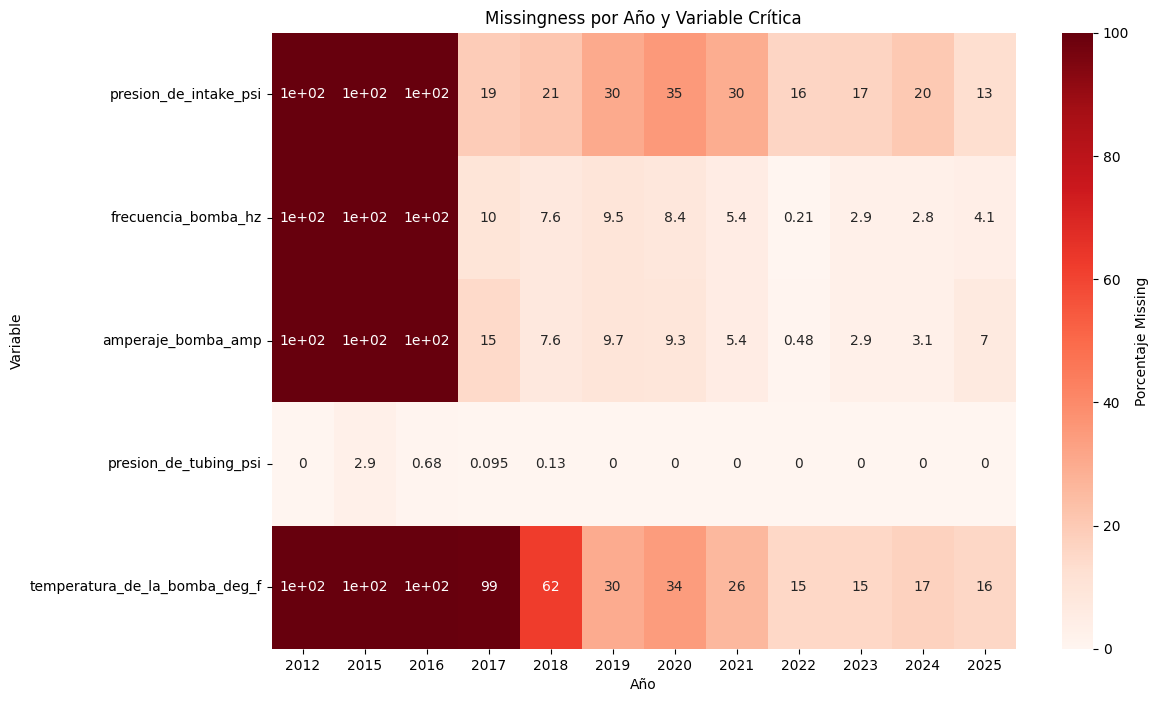

In [64]:
# Visualización: Heatmap de missingness por año
plt.figure(figsize=(12, 8))
sns.heatmap(missing_by_year.T, annot=True, cmap='Reds', cbar_kws={'label': 'Porcentaje Missing'})
plt.title('Missingness por Año y Variable Crítica')
plt.ylabel('Variable')
plt.xlabel('Año')
plt.show()

In [65]:
# Missingness por pozo (si existe columna 'name_')
if 'name_' in df.columns:
    missing_by_pozo = df.groupby('name_').apply(lambda x: (x.isnull().sum() / len(x)) * 100)
    print("Promedio de missingness por pozo (top 10):")
    print(missing_by_pozo.mean().sort_values(ascending=False).head(10))
else:
    print("Columna 'name_' no encontrada. Ajustar si hay otra columna de identificación de pozo.")

Promedio de missingness por pozo (top 10):
Unnamed: 23                     100.00
presion_de_casing_psi            61.02
temperatura_de_la_bomba_deg_f    34.38
presion_de_intake_psi            27.59
amperaje_bomba_amp               16.47
frecuencia_bomba_hz              15.59
salinidad_ppm_pu                 11.05
pint_lo                           9.30
etapas_de_la_bomba                9.21
tipo_de_bomba                     8.68
dtype: float64


## 5. Análisis de Correlaciones en Dataset Crudo

Analizamos correlaciones en el dataset original sin filtrar variables, usando Pearson (lineal) y Mutual Information (no lineal). Esto ayuda a identificar redundancias antes de eliminar variables.

In [95]:
# Seleccionar variables numéricas predictoras
# Eliminando variables derivadas (_eff, _p) para reducir multicolinealidad perfecta
variables_predictoras = [
    'prueba_de_produccion_petróleo_a_24_horas_bbld',  # Manteniendo oil, eliminando water por redundancia
    'prueba_de_producción_gas_a_24_horas_mcfd', 'bsw_pct', 'gravedad_api_del_petroleo',
    'salinidad_ppm_pu', 'presion_de_intake_psi', 'frecuencia_bomba_hz', 'amperaje_bomba_amp',
    'presion_de_tubing_psi', 'presion_de_casing_psi', 'temperatura_de_la_bomba_deg_f',
    'etapas_de_la_bomba', 'delta_1', 'slope_7', 'slope_14', 'qtot_lo', 'qtot_hi',
    'gas_hi', 'hz_hi', 'pint_lo', 'env_q', 'env_gate',
    'slope7_mean', 'slope7_std', 'Qt_prev14', 'ratio14'
]

df_numeric_crudo = df[variables_predictoras].select_dtypes(include=[np.number])

print(f"Dataset crudo numérico: {df_numeric_crudo.shape[0]} filas, {df_numeric_crudo.shape[1]} columnas")
print(f"Valores faltantes totales: {df_numeric_crudo.isnull().sum().sum()}")

Dataset crudo numérico: 16161 filas, 26 columnas
Valores faltantes totales: 37958


## Análisis de Eliminación de Variable de Producción de Agua

Se eliminó la variable "prueba_de_producción_agua_a_24_horas_bbld" debido a que presenta dependencia lineal exacta con la producción total y la producción de petróleo (q_total = oil + water), lo que introduce redundancia determinística y multicolinearidad perfecta. Por tanto, se mantuvieron las variables físicamente no redundantes (q_total, oil y BSW%) para preservar interpretabilidad y estabilidad del modelo.

Esto reduce la dimensionalidad y evita problemas en modelos lineales, permitiendo enfocarnos en variables independientes.

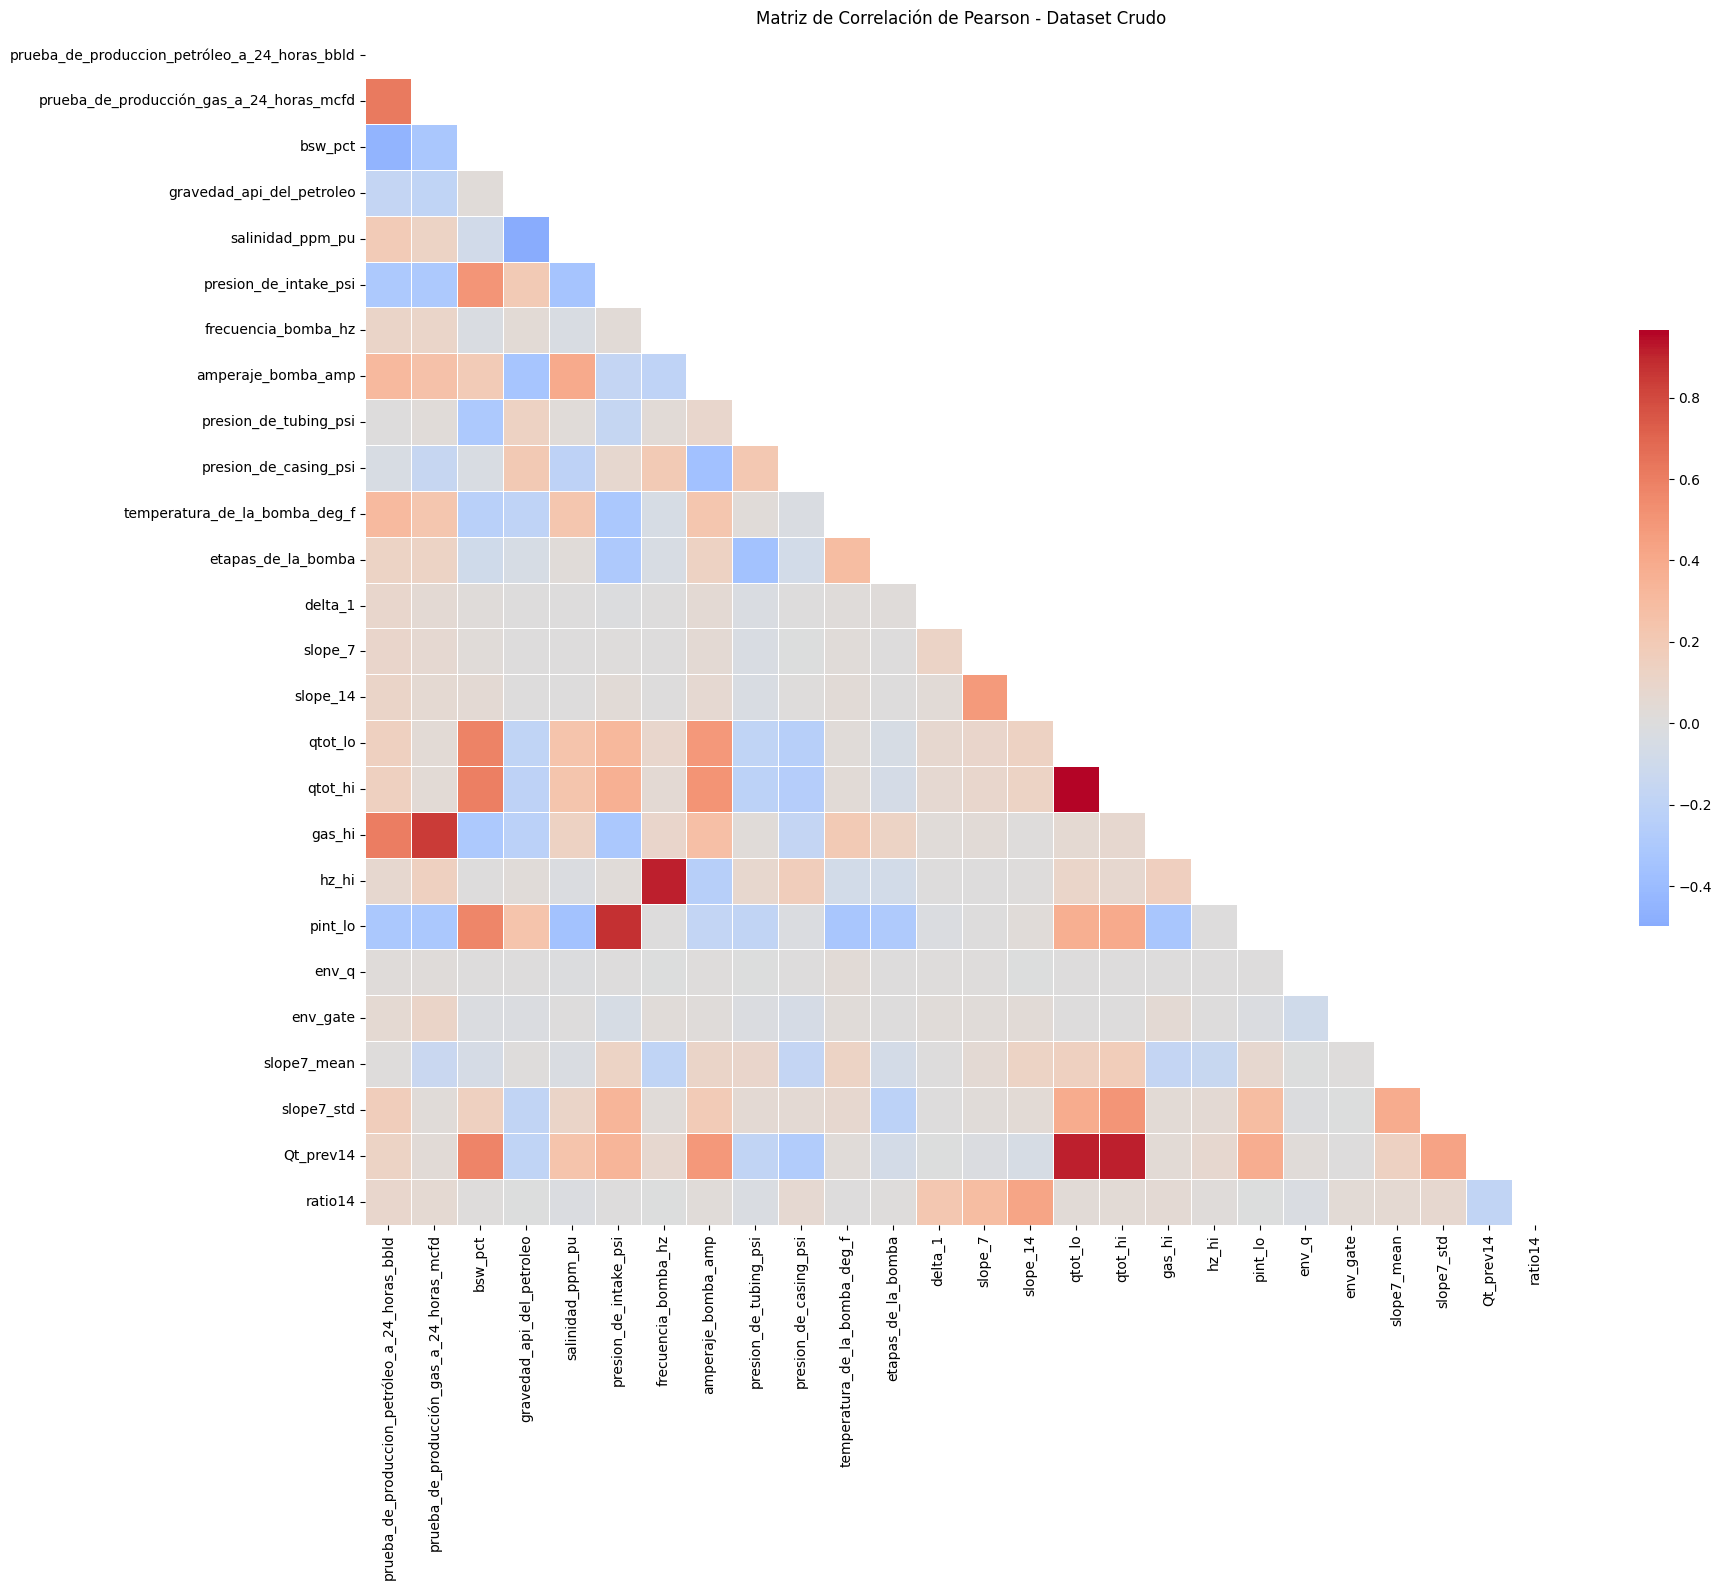

In [104]:
# Correlación de Pearson (ignora NaN pairwise)
corr_pearson_crudo = df_numeric_crudo.corr(method='pearson')

# Heatmap de correlaciones
plt.figure(figsize=(20, 16))
mask = np.triu(np.ones_like(corr_pearson_crudo, dtype=bool))
sns.heatmap(corr_pearson_crudo, mask=mask, annot=False, cmap='coolwarm', center=0,
            square=True, linewidths=.5, cbar_kws={"shrink": .5})
plt.title('Matriz de Correlación de Pearson - Dataset Crudo')
plt.tight_layout()
plt.show()

In [105]:
# Correlaciones más altas (|r| > 0.8)
corr_pairs_crudo = corr_pearson_crudo.where(np.triu(np.ones_like(corr_pearson_crudo), k=1).astype(bool))
high_corr_crudo = corr_pairs_crudo.stack().sort_values(ascending=False)

print("Correlaciones de Pearson más altas en crudo (|r| > 0.8):")
print(high_corr_crudo[abs(high_corr_crudo) > 0.8].head(20))

Correlaciones de Pearson más altas en crudo (|r| > 0.8):
qtot_lo                                   qtot_hi     0.97
qtot_hi                                   Qt_prev14   0.92
qtot_lo                                   Qt_prev14   0.92
frecuencia_bomba_hz                       hz_hi       0.91
presion_de_intake_psi                     pint_lo     0.88
prueba_de_producción_gas_a_24_horas_mcfd  gas_hi      0.84
dtype: float64


In [98]:
# Mutual Information con filas completas
df_mi_crudo = df_numeric_crudo.dropna()
if not df_mi_crudo.empty:
    X_crudo = df_mi_crudo
    y_crudo = df.loc[df_mi_crudo.index, 'pred_evento']
    mi_scores_crudo = mutual_info_regression(X_crudo, y_crudo, random_state=42)
    mi_df_crudo = pd.DataFrame({'Variable': X_crudo.columns, 'MI_Score': mi_scores_crudo}).sort_values('MI_Score', ascending=False)
    
    print("Scores de Mutual Information en crudo (top 10):")
    print(mi_df_crudo.head(10))
else:
    print("No hay filas completas para calcular MI en crudo.")

Scores de Mutual Information en crudo (top 10):
                                         Variable  MI_Score
25                                        ratio14      0.19
20                                          env_q      0.17
13                                        slope_7      0.16
1        prueba_de_producción_gas_a_24_horas_mcfd      0.14
4                                salinidad_ppm_pu      0.13
12                                        delta_1      0.13
14                                       slope_14      0.11
0   prueba_de_produccion_petróleo_a_24_horas_bbld      0.09
16                                        qtot_hi      0.09
17                                         gas_hi      0.08


## 6. Eliminación de Variables Redundantes

Basado en correlaciones altas y MI baja, eliminamos variables redundantes para reducir dimensionalidad y evitar multicolinealidad en modelos.

In [107]:
# Lista de variables a eliminar (basado en análisis previo)
variables_a_eliminar = [
    'qtot_lo_eff', 'qtot_hi_eff', 'hz_hi_eff', 'gas_hi_eff', 'pint_lo_eff',
    'qtot_lo', 'qtot_hi', 'hz_hi', 'gas_hi', 'pint_lo', 'Qt_prev14',
    'slope_14', 'delta_3', 'qtot_lo_p', 'qtot_hi_p', 'gas_hi_p', 'hz_hi_p', 'pint_lo_p',
    'env_gate', 'slope7_mean', 'slope7_std', 'd1_p',
    'evento_hibrido', 'regimen_id', 'confirm', 'enough', 'fuera_inst',
    'alarma_instantanea', 'persist', 'persist_ref', 'prueba_de_producción_agua_a_24_horas_bbld','prueba_pozooil_24__prueba_pozowater_24'
]

# Filtrar el dataset
df_filtrado = df.drop(columns=variables_a_eliminar, errors='ignore')

print("Variables eliminadas:")
for i, var in enumerate(variables_a_eliminar, 1):
    print(f"{i:2d}. {var}")

print(f"\nDataset después de filtrado: {df_filtrado.shape[0]} filas x {df_filtrado.shape[1]} columnas")
print(f"Columnas restantes: {list(df_filtrado.columns)}")

Variables eliminadas:
 1. qtot_lo_eff
 2. qtot_hi_eff
 3. hz_hi_eff
 4. gas_hi_eff
 5. pint_lo_eff
 6. qtot_lo
 7. qtot_hi
 8. hz_hi
 9. gas_hi
10. pint_lo
11. Qt_prev14
12. slope_14
13. delta_3
14. qtot_lo_p
15. qtot_hi_p
16. gas_hi_p
17. hz_hi_p
18. pint_lo_p
19. env_gate
20. slope7_mean
21. slope7_std
22. d1_p
23. evento_hibrido
24. regimen_id
25. confirm
26. enough
27. fuera_inst
28. alarma_instantanea
29. persist
30. persist_ref
31. prueba_de_producción_agua_a_24_horas_bbld
32. prueba_pozooil_24__prueba_pozowater_24

Dataset después de filtrado: 16161 filas x 23 columnas
Columnas restantes: ['name_', 'date', 'prueba_de_produccion_petróleo_a_24_horas_bbld', 'prueba_de_producción_gas_a_24_horas_mcfd', 'bsw_pct', 'gravedad_api_del_petroleo', 'salinidad_ppm_pu', 'presion_de_intake_psi', 'frecuencia_bomba_hz', 'amperaje_bomba_amp', 'presion_de_tubing_psi', 'presion_de_casing_psi', 'tipo_de_bomba', 'temperatura_de_la_bomba_deg_f', 'etapas_de_la_bomba', 'campo', 'delta_1', 'slope_7', 'Un

## 7. Análisis de Correlaciones en Dataset Filtrado

Repetimos el análisis en el dataset filtrado para validar que las correlaciones mejoran y las variables restantes son relevantes.

In [108]:
# Variables numéricas en el dataset filtrado
df_numeric_filtrado = df_filtrado.select_dtypes(include=[np.number])

print(f"Dataset filtrado numérico: {df_numeric_filtrado.shape[0]} filas, {df_numeric_filtrado.shape[1]} columnas")
print(f"Valores faltantes totales: {df_numeric_filtrado.isnull().sum().sum()}")

Dataset filtrado numérico: 16161 filas, 18 columnas
Valores faltantes totales: 33722


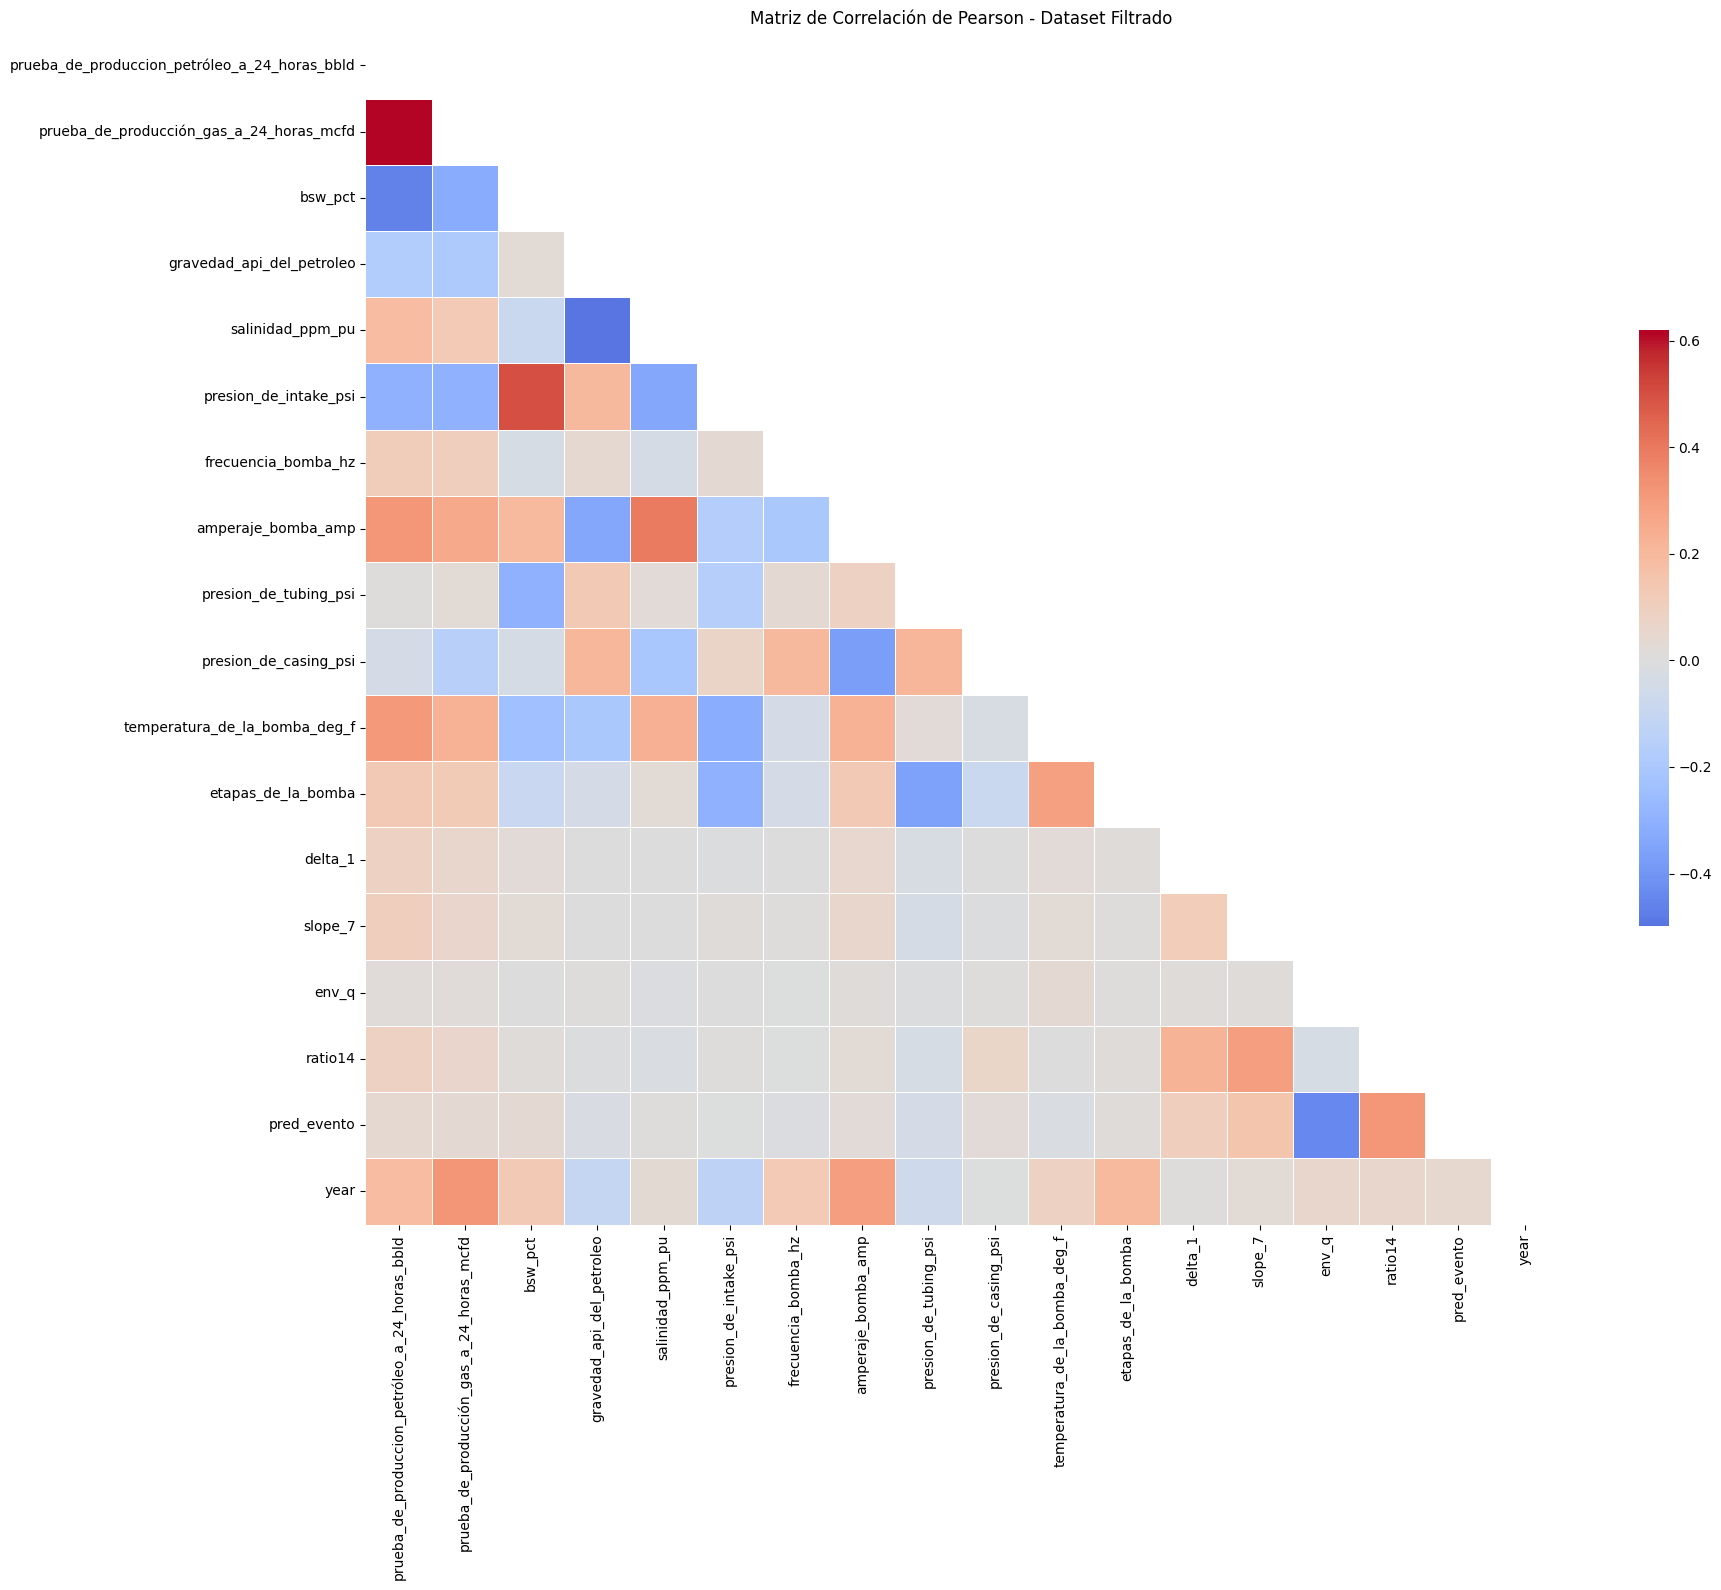

In [109]:
# Correlación de Pearson en filtrado
corr_pearson_filtrado = df_numeric_filtrado.corr(method='pearson')

# Heatmap
plt.figure(figsize=(20, 16))
mask = np.triu(np.ones_like(corr_pearson_filtrado, dtype=bool))
sns.heatmap(corr_pearson_filtrado, mask=mask, annot=False, cmap='coolwarm', center=0,
            square=True, linewidths=.5, cbar_kws={"shrink": .5})
plt.title('Matriz de Correlación de Pearson - Dataset Filtrado')
plt.tight_layout()
plt.show()

In [114]:
# --- ANÁLISIS AVANZADO DE MULTICOLINEALIDAD Y RELACIONES CLAVE EN ESP ---

import scipy.stats as stats
from statsmodels.stats.outliers_influence import variance_inflation_factor

# A) Correlación global y por pozo
pares_clave = [
    ("gravedad_api_del_petroleo", "salinidad_ppm_pu"),
    ("prueba_de_producción_gas_a_24_horas_mcfd", "prueba_de_produccion_petróleo_a_24_horas_bbld"),
    ("bsw_pct", "salinidad_ppm_pu"),
    ("bsw_pct", "presion_de_intake_psi")
]

print("A) Correlación global y por pozo\n")
for v1, v2 in pares_clave:
    if v1 in df.columns and v2 in df.columns:
        # Pearson y Spearman global
        pearson = df[[v1, v2]].corr(method="pearson").iloc[0,1]
        spearman = df[[v1, v2]].corr(method="spearman").iloc[0,1]
        print(f"{v1} vs {v2} - Pearson global: {pearson:.3f}, Spearman global: {spearman:.3f}")

        # Por pozo
        if "name_" in df.columns:
            corrs_pearson = df.groupby("name_")[[v1, v2]].corr(method="pearson").iloc[0::2,1].dropna()
            corrs_spearman = df.groupby("name_")[[v1, v2]].corr(method="spearman").iloc[0::2,1].dropna()
            for label, corrs in [("Pearson", corrs_pearson), ("Spearman", corrs_spearman)]:
                med = corrs.median()
                iqr = corrs.quantile(0.75) - corrs.quantile(0.25)
                print(f"  {label} por pozo: media={corrs.mean():.3f}, mediana={med:.3f}, IQR={iqr:.3f}, min={corrs.min():.3f}, max={corrs.max():.3f}")
        print("-" * 60)

# B) Cross-correlation con lags
def crosscorr_lags(x, y, lags=14):
    result = []
    for lag in range(-lags, lags+1):
        if lag < 0:
            corr = x[:lag].corr(y[-lag:])
        elif lag > 0:
            corr = x[lag:].corr(y[:-lag])
        else:
            corr = x.corr(y)
        result.append((lag, corr))
    return result

print("\nB) Cross-correlation con lags\n")
pares_lags = [
    ("prueba_de_producción_gas_a_24_horas_mcfd", "prueba_de_produccion_petróleo_a_24_horas_bbld"),
    ("presion_de_intake_psi", "bsw_pct")
]
for v1, v2 in pares_lags:
    if v1 in df.columns and v2 in df.columns:
        lags_corr = crosscorr_lags(df[v1].dropna(), df[v2].dropna())
        lags_corr = [lc for lc in lags_corr if lc[1] is not None]
        if lags_corr:
            max_lag, max_corr = max(lags_corr, key=lambda x: abs(x[1]))
            print(f"{v1} vs {v2}: máximo |corr|={max_corr:.3f} en lag={max_lag}")
print("-" * 60)

# C) VIF y clusters de correlación
print("\nC) Diagnóstico de multicolinealidad (VIF y clusters)\n")
features = [v for v in df.select_dtypes(include=[float, int]).columns if v not in ["pred_evento", "name_", "date"]]
X = df[features].dropna()
vif_data = pd.DataFrame()
vif_data["feature"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
print(vif_data.sort_values("VIF", ascending=False).head(10))

# Clusters de alta correlación
corr_matrix = X.corr().abs()
clusters = []
used = set()
for col in corr_matrix.columns:
    if col in used:
        continue
    cluster = [col]
    for other in corr_matrix.columns:
        if other != col and corr_matrix.loc[col, other] >= 0.85:
            cluster.append(other)
            used.add(other)
    if len(cluster) > 1:
        clusters.append(cluster)
        used.update(cluster)
print("\nClusters de variables altamente correlacionadas (|r|>=0.85):")
for cluster in clusters:
    print(cluster)


A) Correlación global y por pozo

gravedad_api_del_petroleo vs salinidad_ppm_pu - Pearson global: -0.499, Spearman global: -0.378
  Pearson por pozo: media=-0.023, mediana=-0.008, IQR=0.586, min=-0.932, max=0.710
  Spearman por pozo: media=-0.032, mediana=0.047, IQR=0.791, min=-0.813, max=0.791
------------------------------------------------------------
prueba_de_producción_gas_a_24_horas_mcfd vs prueba_de_produccion_petróleo_a_24_horas_bbld - Pearson global: 0.619, Spearman global: 0.616
  Pearson por pozo: media=0.478, mediana=0.670, IQR=0.867, min=-0.735, max=1.000
  Spearman por pozo: media=0.584, mediana=0.779, IQR=0.743, min=-0.270, max=0.999
------------------------------------------------------------
bsw_pct vs salinidad_ppm_pu - Pearson global: -0.087, Spearman global: -0.368
  Pearson por pozo: media=-0.069, mediana=-0.100, IQR=0.491, min=-0.811, max=0.875
  Spearman por pozo: media=-0.038, mediana=-0.057, IQR=0.834, min=-0.713, max=0.759
------------------------------------

## CONCLUSIÓN
Por lo tanto la colinealidad existe en variables calculada para obtener nuestra variable pred_evento. En las varaibles crudas se realizo evaluación de ingeniería donde se determina que deben mantenerse tales features para entrenar el modelo

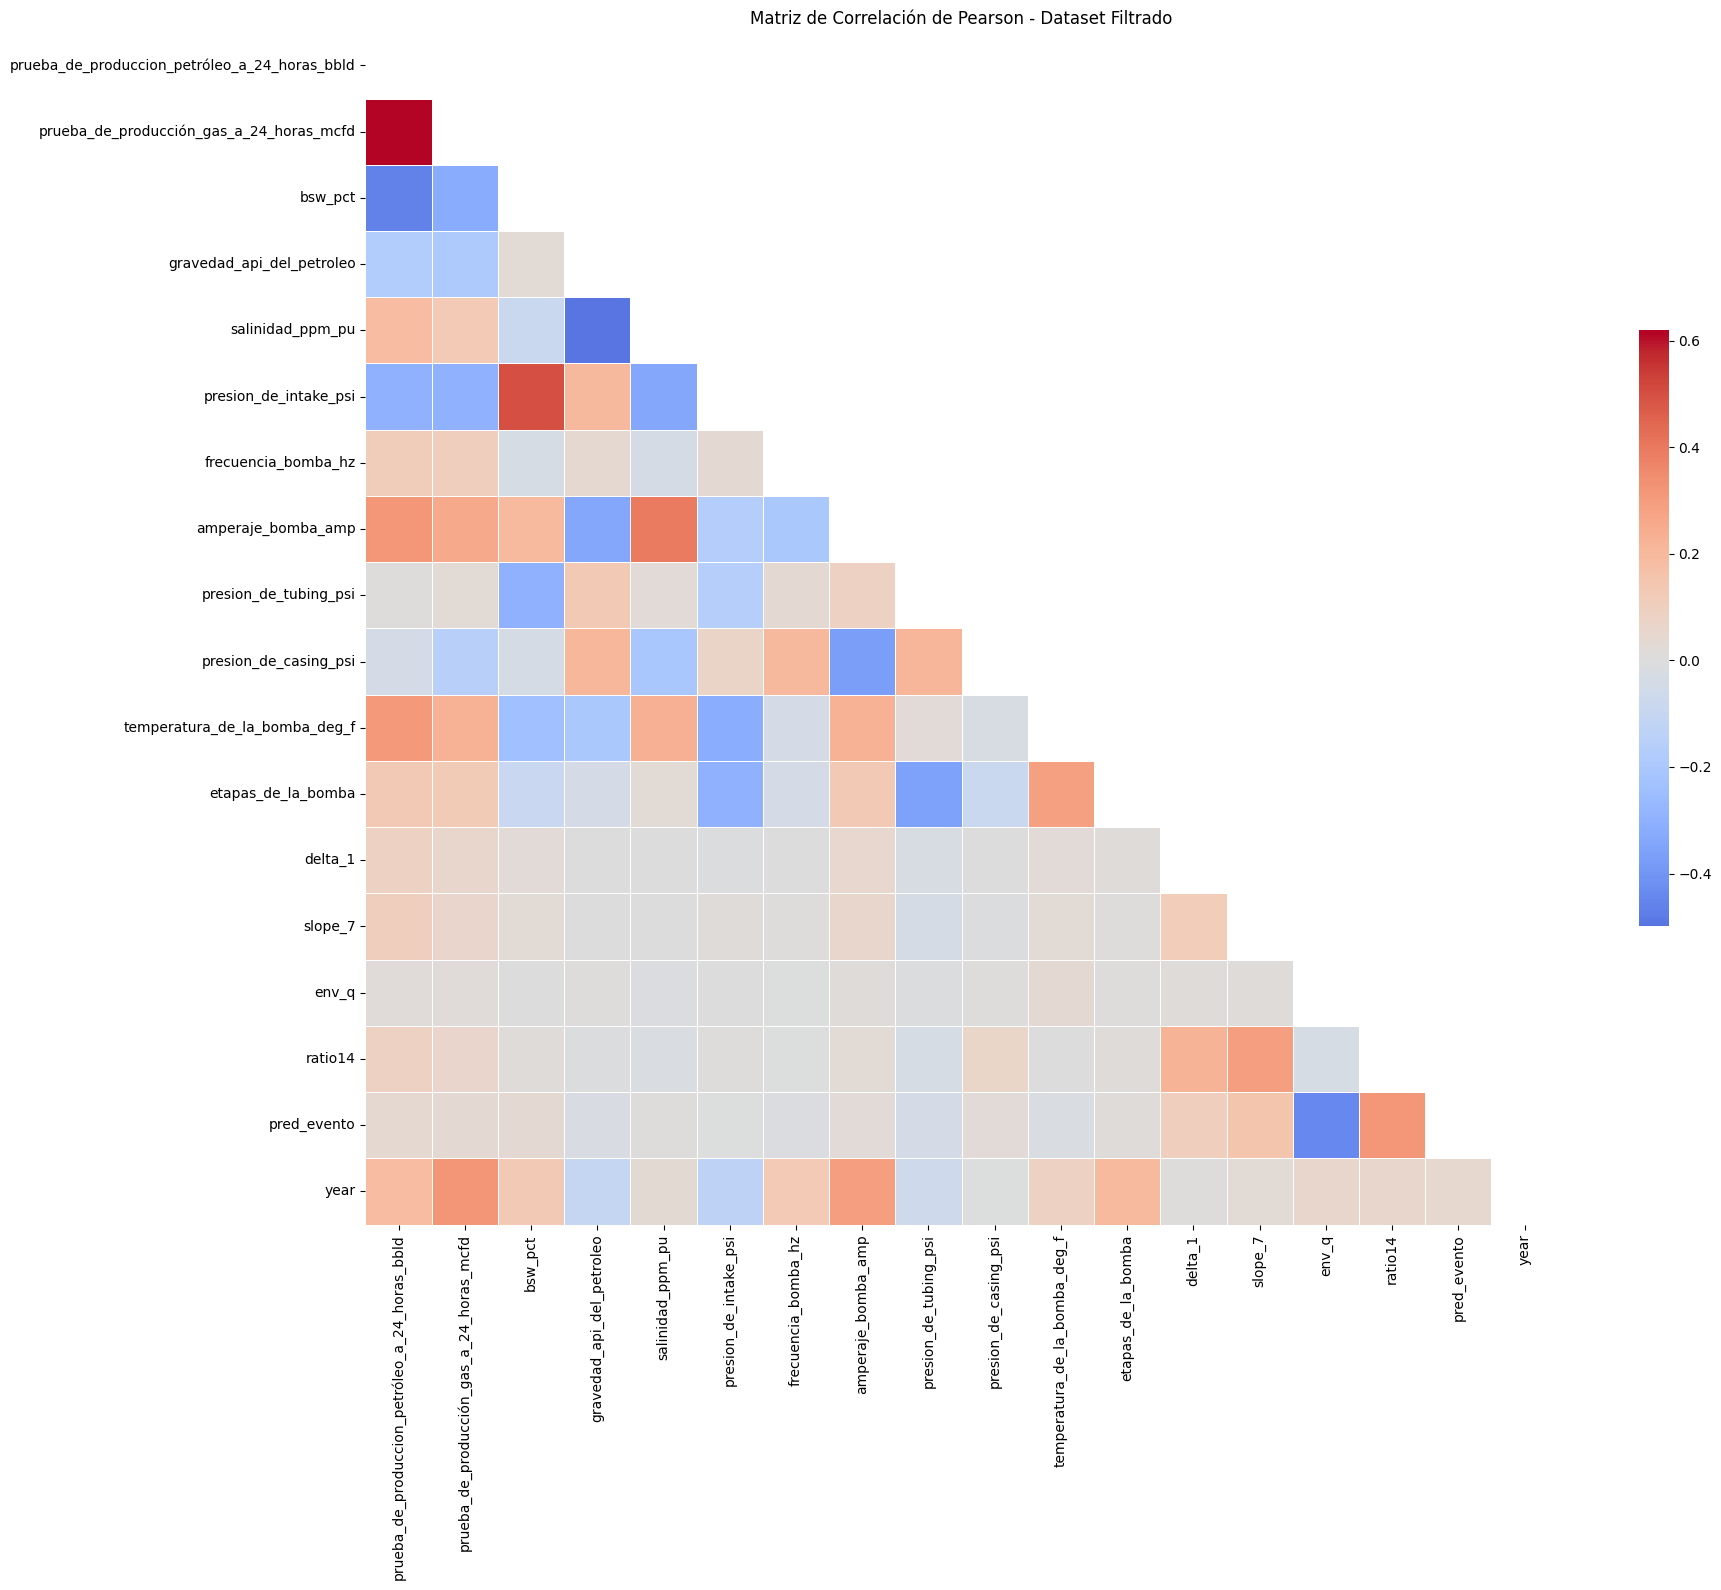

In [ ]:
# Correlación de Pearson en filtrado
corr_pearson_filtrado = df_numeric_filtrado.corr(method='pearson')

# Heatmap
plt.figure(figsize=(20, 16))
mask = np.triu(np.ones_like(corr_pearson_filtrado, dtype=bool))
sns.heatmap(corr_pearson_filtrado, mask=mask, annot=False, cmap='coolwarm', center=0,
            square=True, linewidths=.5, cbar_kws={"shrink": .5})
plt.title('Matriz de Correlación de Pearson - Dataset Filtrado')
plt.tight_layout()
plt.show()

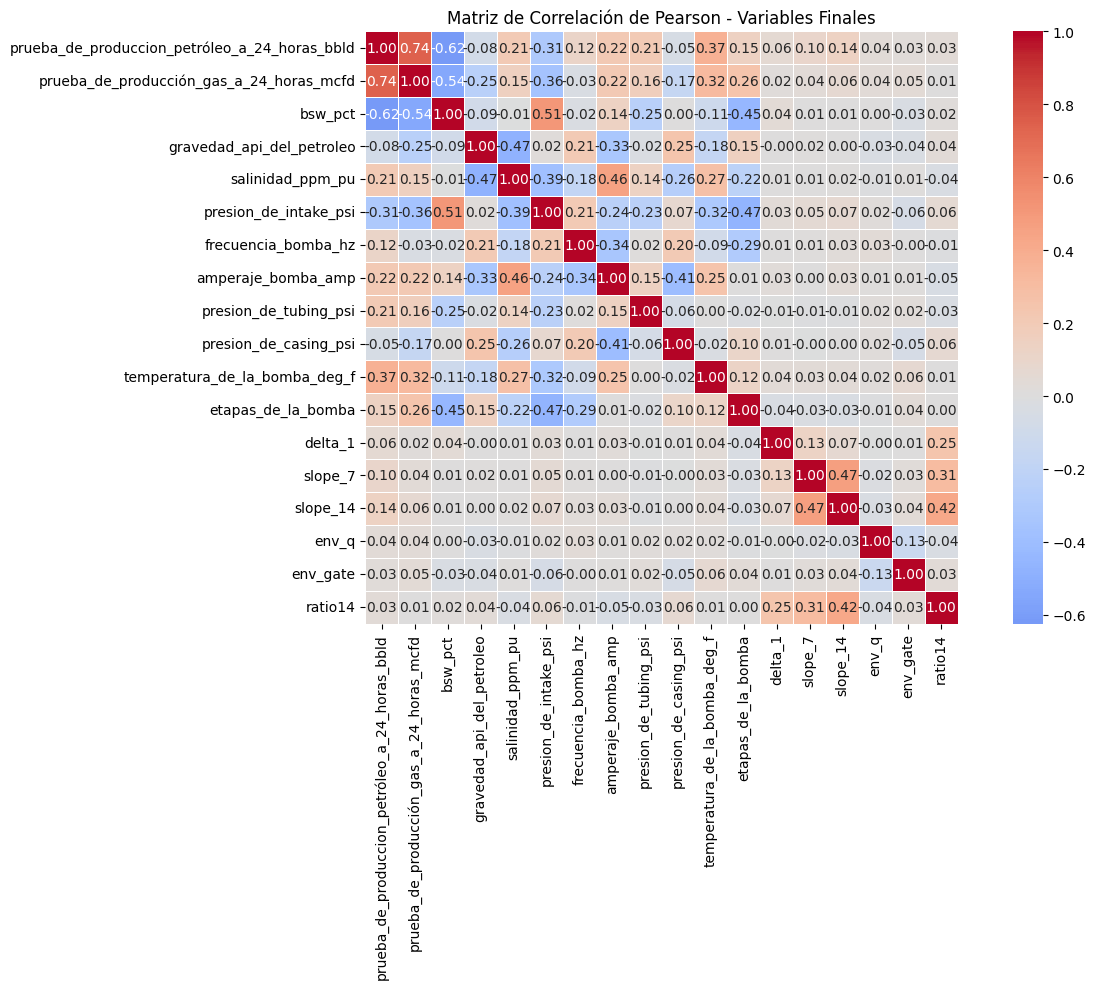

No se detectaron pares con |r| > 0.85.


,Variable,VIF
10,temperatura_de_la_bomba_deg_f,82.29
3,gravedad_api_del_petroleo,40.53
11,etapas_de_la_bomba,17.54
2,bsw_pct,15.65
7,amperaje_bomba_amp,12.78
0,prueba_de_produccion_petróleo_a_24_horas_bbld,11.10
6,frecuencia_bomba_hz,9.30
5,presion_de_intake_psi,5.44
1,prueba_de_producción_gas_a_24_horas_mcfd,5.34
4,salinidad_ppm_pu,3.93


Interpretación: VIF > 5 indica posible multicolinealidad, VIF > 10 es severa.


In [116]:
# Diagnóstico de multicolinealidad en las 18 variables finales

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Variables finales (sin la variable objetivo para VIF y correlación entre features)
variables_finales = [
    'prueba_de_produccion_petróleo_a_24_horas_bbld',
    'prueba_de_producción_gas_a_24_horas_mcfd',
    'bsw_pct',
    'gravedad_api_del_petroleo',
    'salinidad_ppm_pu',
    'presion_de_intake_psi',
    'frecuencia_bomba_hz',
    'amperaje_bomba_amp',
    'presion_de_tubing_psi',
    'presion_de_casing_psi',
    'temperatura_de_la_bomba_deg_f',
    'etapas_de_la_bomba',
    'delta_1',
    'slope_7',
    'slope_14',
    'env_q',
    'env_gate',
    'ratio14'
]

df_final = df[variables_finales].dropna()

# Matriz de correlación Pearson
corr_matrix = df_final.corr()
plt.figure(figsize=(14, 10))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0, square=True, linewidths=.5)
plt.title('Matriz de Correlación de Pearson - Variables Finales')
plt.tight_layout()
plt.show()

# Identificar pares con |r| > 0.85
high_corr = []
for i in range(len(variables_finales)):
    for j in range(i+1, len(variables_finales)):
        r = corr_matrix.iloc[i, j]
        if abs(r) > 0.85:
            high_corr.append((variables_finales[i], variables_finales[j], r))
if high_corr:
    print('Pares de variables con |r| > 0.85:')
    for v1, v2, r in high_corr:
        print(f'{v1} vs {v2}: r = {r:.2f}')
else:
    print('No se detectaron pares con |r| > 0.85.')

# Calcular VIF para cada variable
X = df_final.copy()
vif_data = pd.DataFrame()
vif_data['Variable'] = X.columns
vif_data['VIF'] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
display(vif_data.sort_values('VIF', ascending=False))

print('Interpretación: VIF > 5 indica posible multicolinealidad, VIF > 10 es severa.')

### Decisión sobre multicolinealidad y variables finales

El análisis de VIF mostró valores elevados en variables operativas clave, reflejando acoplamientos físicos propios del sistema ESP. No se eliminaron variables adicionales por VIF alto, ya que los modelos basados en árboles de decisión no se ven afectados negativamente por la multicolinealidad y pueden aprovechar la información redundante. La depuración del set predictor se limitó a excluir variables determinísticas y asociadas al sistema de etiquetado (como `env_q` y `env_gate`) para evitar fuga de información.

**Conclusión:** El conjunto final de variables mantiene relevancia física y capacidad predictiva, priorizando interpretabilidad y robustez sobre criterios puramente estadísticos.

In [118]:
# Preparación del dataset final para entrenamiento (sin eliminar filas con NaN en variables predictoras)

# Selección de variables finales (sin variables determinísticas ni de fuga de información)
variables_finales = [
    'prueba_de_produccion_petróleo_a_24_horas_bbld',
    'prueba_de_producción_gas_a_24_horas_mcfd',
    'bsw_pct',
    'gravedad_api_del_petroleo',
    'salinidad_ppm_pu',
    'presion_de_intake_psi',
    'frecuencia_bomba_hz',
    'amperaje_bomba_amp',
    'presion_de_tubing_psi',
    'presion_de_casing_psi',
    'temperatura_de_la_bomba_deg_f',
    'etapas_de_la_bomba',
    'delta_1',
    'slope_7',
    'slope_14',
    'ratio14'
]

# Variable objetivo
objetivo = 'pred_evento'

#Incluyendo Fecha
variables_con_fecha = ['date'] + variables_finales + [objetivo] if 'date' in df.columns else variables_finales + [objetivo]

# NO eliminar filas con NaN en las variables predictoras, solo asegurar que la variable objetivo no tenga NaN
if 'date' in df.columns:
    df_entrenamiento = df[variables_con_fecha][~df[objetivo].isna()].copy()
else:
    df_entrenamiento = df[variables_finales + [objetivo]][~df[objetivo].isna()].copy()

print(f"Dataset final para entrenamiento (sin eliminar filas por NaN en predictoras): {df_entrenamiento.shape[0]} filas x {df_entrenamiento.shape[1]} columnas")
df_entrenamiento.head()

Dataset final para entrenamiento (sin eliminar filas por NaN en predictoras): 16161 filas x 18 columnas


,date,prueba_de_produccion_petróleo_a_24_horas_bbld,prueba_de_producción_gas_a_24_horas_mcfd,bsw_pct,gravedad_api_del_petroleo,salinidad_ppm_pu,presion_de_intake_psi,frecuencia_bomba_hz,amperaje_bomba_amp,presion_de_tubing_psi,presion_de_casing_psi,temperatura_de_la_bomba_deg_f,etapas_de_la_bomba,delta_1,slope_7,slope_14,ratio14,pred_evento
0,2015-02-02,204.37,14.00,68.07,22.40,NaN,NaN,NaN,NaN,100.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
1,2015-02-09,216.90,14.00,75.05,22.40,NaN,NaN,NaN,NaN,50.00,NaN,NaN,NaN,229.43,NaN,NaN,NaN,2
2,2015-03-05,99.29,14.00,73.92,22.40,NaN,NaN,NaN,NaN,290.00,NaN,NaN,NaN,-488.75,-129.66,NaN,NaN,1
3,2015-04-05,205.33,14.00,74.02,22.40,NaN,NaN,NaN,NaN,260.00,NaN,NaN,NaN,409.70,-3.76,NaN,NaN,1
4,2015-04-07,214.01,14.00,75.00,22.40,NaN,NaN,NaN,NaN,50.00,NaN,NaN,NaN,65.55,35.28,35.28,NaN,2


## 8. Freeze y Exportación del Dataset Final para Entrenamiento

En esta sección se guarda el dataset final de entrenamiento en formato CSV en la carpeta `freeze/` y se documenta la metadata relevante para asegurar reproducibilidad y trazabilidad del proceso.

**Buenas prácticas aplicadas:**
- Exportación con index desactivado.
- Documentación de variables, fecha de freeze y shape.
- Uso de nombres claros y versionado en el archivo.
- Metadata guardada en formato JSON para fácil consulta.

In [119]:
# Exportar dataset final a CSV (freeze) y guardar metadata JSON
import json
from datetime import datetime

# Ruta de exportación
freeze_folder = project_root.parent / 'freeze'
freeze_folder.mkdir(exist_ok=True)
fecha_freeze = datetime.now().strftime('%Y%m%d_%H%M%S')
nombre_csv = f'df_entrenamiento_v1_{fecha_freeze}.csv'
nombre_json = f'df_entrenamiento_v1_{fecha_freeze}_metadata.json'

# Exportar CSV limpio
df_entrenamiento.to_csv(freeze_folder / nombre_csv, index=False)

# Preparar metadata
metadata = {
    'archivo_csv': nombre_csv,
    'fecha_freeze': fecha_freeze,
    'shape': list(df_entrenamiento.shape),
    'variables': list(df_entrenamiento.columns),
    'descripcion': 'Dataset final para entrenamiento de predicción de eventos ESP. Incluye todas las filas excepto NaN en la variable objetivo. Variables seleccionadas por relevancia física y estadística.'
}

# Guardar metadata en JSON
with open(freeze_folder / nombre_json, 'w', encoding='utf-8') as f:
    json.dump(metadata, f, ensure_ascii=False, indent=4)

print(f"Dataset exportado a: {freeze_folder / nombre_csv}")
print(f"Metadata guardada en: {freeze_folder / nombre_json}")

Dataset exportado a: c:\Users\Vìctor\OneDrive\Desktop\ESP_Project\freeze\df_entrenamiento_v1_20251228_200900.csv
Metadata guardada en: c:\Users\Vìctor\OneDrive\Desktop\ESP_Project\freeze\df_entrenamiento_v1_20251228_200900_metadata.json
